In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

## Problem *2.11

### (a)

In [35]:
# Given impulse responses
h1 = np.ones((1,5)).flatten()
h2 = np.array([1,-1,-1,-1,1])
h3 = np.ones((1,3)).flatten()

# Using table 2.3
h_distributive = h1 + h2
h_associative = np.convolve(h3, h_distributive)
h_associative

array([2., 2., 2., 0., 2., 2., 2.])

### (b)

In [45]:
# random input
step_input = np.ones(20)  # Step function

# Compute individual step response
y1_individual = np.convolve(h1, step_input)
y2_individual = np.convolve(h2, step_input)
y_individual = np.convolve(h3, y1_individual+y2_individual)

# Compute total step response
y_total = np.convolve(h_associative, step_input)

print(y_individual)
print(y_total)

[ 2.  4.  6.  6.  8. 10. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12.
 12. 12. 10.  8.  6.  6.  4.  2.]
[ 2.  4.  6.  6.  8. 10. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12. 12.
 12. 12. 10.  8.  6.  6.  4.  2.]


They are indeed equivalent.

## Problem 2.17

### (a)

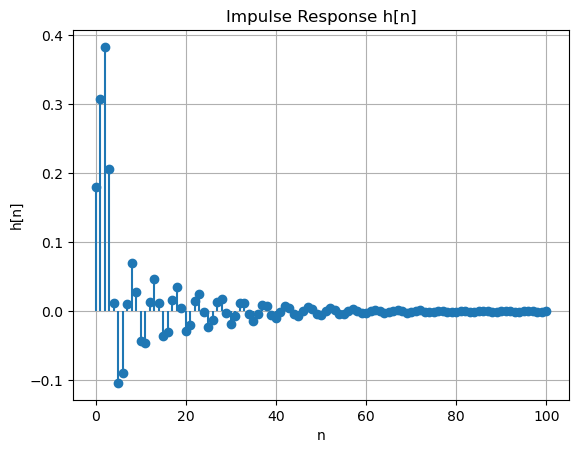

In [14]:
# Define the coefficients
a = [1, -1.15, 1.5, -0.7, 0.25]  # Denominator
b = [0.18, 0.1, 0.3, 0.1, 0.18]  # Numerator

# Compute the impulse response for 101 samples
n = np.arange(101)  # Time index from 0 to 100
_, h = signal.dimpulse((b, a, 1), n=len(n))  # Compute impulse response
h = np.squeeze(h)  # Convert to 1D array

# Plot the impulse response
plt.figure()
plt.stem(n, h, basefmt=" ")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.title("Impulse Response h[n]")
plt.grid()
plt.show()

### (b)

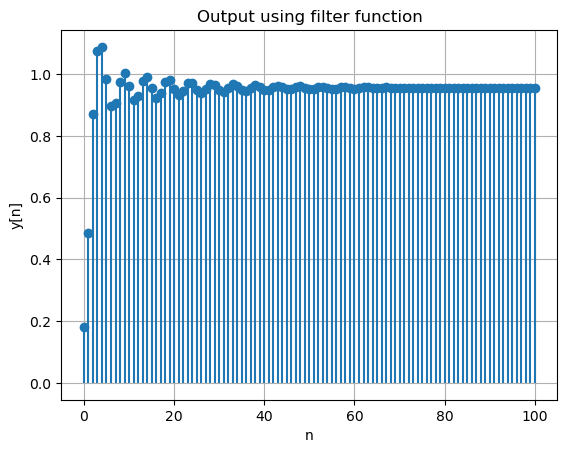

In [8]:
# Step response (b) with x[n] = u[n]
u = np.ones(len(n))  # Step input
y_filter = signal.lfilter(b, a, u)  # Compute output using filter

plt.figure()
plt.stem(n, y_filter, basefmt=" ")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("Output using filter function")
plt.grid()
plt.show()

### (c)

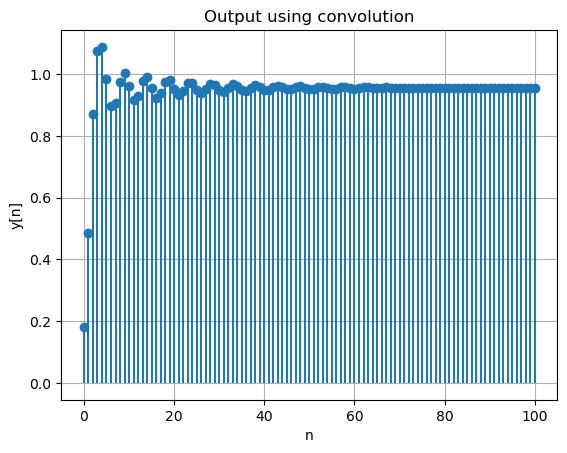

In [11]:
# Compute y[n] using convolution (c)
y_conv = np.convolve(h, u)[:len(n)]

plt.figure()
plt.stem(n, y_conv, basefmt=" ")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("Output using convolution")
plt.grid()
plt.show()

### (d)

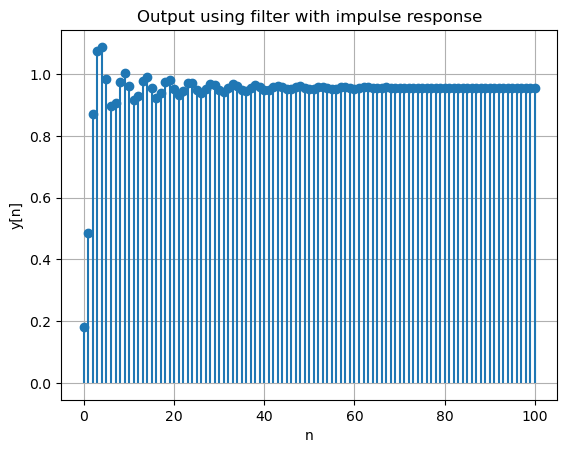

In [12]:
# Compute y[n] using filtering with impulse response (d)
y_filter_h = signal.lfilter(h, [1], u)

plt.figure()
plt.stem(n, y_filter_h, basefmt=" ")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("Output using filter with impulse response")
plt.grid()
plt.show()

## Problem *2.40
Consider the following discrete-time system
$$
y[n] = 10 x[n] \cos(0.25 \pi n + \theta)
$$
where $\theta$ is a constant. Check if the system is

### (a) Linear

A linear combination of the input would be
$$
x_{3}[n] = ax_{1}[n] + bx_{2}[n]
$$
Using this in the output would result in
$$
\begin{align*}
y_{3}[n] &= 10 x_{3}[n] \cos(0.25\pi n + \theta)\\
&= 10 (ax_{1}[n] + bx_{2}[n]) \cos(0.25\pi n + \theta)\\
&= 10 a x_{1}[n] \cos(0.25\pi n + \theta) + 10 b x_{2}[n] \cos(0.25\pi n + \theta)\\
&= a 10 x_{1}[n] \cos(0.25\pi n + \theta) + b 10 x_{2}[n] \cos(0.25\pi n + \theta)
\end{align*}
$$
A linear combination of the output would lead to the following expression
$$
\begin{align*}
y_{3}(t) &= ay_{1}(t) + by_{2}(t)\\
&= a 10 x_{1}[n] \cos(0.25\pi n + \theta) + b 10 x_{2}[n] \cos(0.25\pi n + \theta)
\end{align*}
$$
Since they do lead to the same expression the system is linear.

### (b) Time invariant

Shifting the input leads to $x[n - n_{0}]$. Inserting this into the output signal gives
$$
y[n] = 10 x[n - n_{0}] \cos(0.25 \pi n + \theta)
$$
However shifting the output signal leads to the following expression
$$
\begin{align*}
y[n - n_{0}] &= 10 x[n - n_{0}] \cos(0.25 \pi (n - n_{0}) + \theta)\\
&= 10 x[n - n_{0}] \cos(0.25 \pi n - 0.25 \pi n_{0} + \theta)
\end{align*}
$$
Since they do not lead to the same expressions, the system is not time-invariant.

### (c) Causal

The system does not depend on any future values of $n$. It is therefore causal.

### (d) Stable

It is known that cosines are bounded, so we only have to look at the $10x[n]$ part. $x[n]$ is assumed to be bounded so that $|x[n]| < M_{x}$ for all $n$, where $M_{x}$ is some positive real number. With this it can be said that $y[n] <= 10x[n] < 10M_{x} \Leftrightarrow y[n] < 10M_{x}$. Since the output is bounded assuming the input is bounded (BIBO criteria satisfied), the system must be stable.

Det er ikke et LTI system, fordi det ikke er tids invariant.